# Volatility Project 04 — Complete Panel Forecasting Pipeline

*A compact, end-to-end template from raw tables to checked future predictions*

## The question

Can information available at the close of date *t* forecast each asset's realized volatility on date *t+1*? The row grain is one asset-date. The primary model-selection metric is pooled out-of-fold RMSE; MAE and mean within-date Spearman rank correlation describe robustness and cross-sectional ordering.

The workflow keeps a final block of dates sealed, maps timestamp splits back to panel rows, and fits every learned transformation inside its training fold. It compares fold-local mean and persistence rules with tuned Ridge and whichever supported boosted-tree packages are installed. A clearly named scikit-learn model is used when optional boosters are unavailable or deliberately disabled.

The generated data only verifies the workflow. Stored output is not evidence about files currently on disk: rerun from top to bottom after replacing the data cell.


In [1]:
from pathlib import Path
import os, platform, warnings
import numpy as np
import pandas as pd
import scipy, sklearn, matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 105, "axes.spines.top": False, "axes.spines.right": False})

def rmse(y_true, prediction):
    return float(np.sqrt(mean_squared_error(y_true, prediction)))

def date_rank_ic(frame, prediction_col):
    values = {}
    for date, group in frame.groupby(TIME_COL, observed=True, sort=True):
        truth, forecast = group[TARGET_COL], group[prediction_col]
        values[date] = np.nan if truth.nunique() < 2 or forecast.nunique() < 2 else truth.corr(forecast, method="spearman")
    return pd.Series(values, name="rank_ic", dtype=float)

def metric_row(frame, prediction_col):
    return {"model": prediction_col, "rmse": rmse(frame[TARGET_COL], frame[prediction_col]),
            "mae": mean_absolute_error(frame[TARGET_COL], frame[prediction_col]),
            "mean_date_rank_ic": date_rank_ic(frame, prediction_col).mean()}

print({"runtime_python": platform.python_version(), "numpy": np.__version__, "scipy": scipy.__version__,
       "pandas": pd.__version__, "sklearn": sklearn.__version__, "matplotlib": matplotlib.__version__,
       "seaborn": sns.__version__})


{'runtime_python': '3.12.0', 'numpy': '2.5.2', 'scipy': '1.17.0', 'pandas': '2.3.3', 'sklearn': '1.8.0', 'matplotlib': '3.10.8', 'seaborn': '0.13.2'}


## Parameters

This is the control panel. Adapt column roles and paths here before touching the recipes. `USE_DEMO=False` requires all six input files and fails immediately when one is absent. `FAST_MODE` only reduces the generated fixture and parameter grids for automated checks.


In [2]:
USE_DEMO = True
TRAIN_OBSERVATIONS_PATH = None
TEST_OBSERVATIONS_PATH = None
LABELS_PATH = None
ASSET_METADATA_PATH = None
MACRO_RELEASES_PATH = None
SAMPLE_OUTPUT_PATH = None

SEED = 17
N_DATES = 150
N_TEST_DATES = 24
N_ENTITIES = 30
N_TRAIN_ENTITIES = 28
FAST_MODE = False

TIME_COL = "date"
ENTITY_COL = "asset_id"
GROUP_COL = "sector"
TARGET_COL = "target_volatility"
ROW_ID_COL = "row_id"
PREDICTION_COL = "prediction"
RELEASE_COL = "release_date"

LABEL_HORIZON = 1
PURGE_DATES = LABEL_HORIZON
N_SPLITS = 4
N_INNER_SPLITS = 3
FINAL_HOLDOUT_FRACTION = 0.18
ROLL_WINDOWS = (5, 20)
SAME_DATE_PANEL_AVAILABLE = False
N_JOBS = 1
FORCE_SKLEARN_BOOSTER = os.getenv("VOLATILITY_PANEL_FORCE_SKLEARN", "0").strip() == "1"

NUMERIC_RAW = ["realized_volatility", "return_1d", "volume", "option_skew"]
REQUIRED_OBSERVATION_COLUMNS = [ROW_ID_COL, TIME_COL, ENTITY_COL, *NUMERIC_RAW]


## Where the data comes from

The default fixture creates six ordinary tables: train and future observations, labels, static asset metadata, timestamped macro releases, and an output template. The last two future-only assets deliberately introduce an unseen sector and missing histories. A few non-finite measurements exercise fold-fitted imputation.

For a Python 3.8.7 environment, create an isolated kernel with release pins whose package metadata supports Python 3.8:

```bash
python3.8 -m venv .venv-panel38
source .venv-panel38/bin/activate
python -m pip install --upgrade "pip==24.3.1"
python -m pip install \
  "numpy==1.24.4" "scipy==1.10.1" "pandas==2.0.3" \
  "scikit-learn==1.3.2" "matplotlib==3.7.5" "seaborn==0.13.2" \
  "jupyterlab==4.2.5" "ipykernel==6.29.5"
python -m pip install "lightgbm==4.3.0" "xgboost==2.0.3"  # optional
python -m ipykernel install --user --name panel-py38 --display-name "Panel Python 3.8.7"
```

The optional packages may be installed separately; having neither does not block the notebook. Their active identities are printed before tuning. Version pages: [pip](https://pypi.org/project/pip/24.3.1/), [NumPy](https://pypi.org/project/numpy/1.24.4/), [pandas](https://pypi.org/project/pandas/2.0.3/), [SciPy](https://pypi.org/project/scipy/1.10.1/), [scikit-learn](https://pypi.org/project/scikit-learn/1.3.2/), [matplotlib](https://pypi.org/project/matplotlib/3.7.5/), [seaborn](https://pypi.org/project/seaborn/0.13.2/), [JupyterLab](https://pypi.org/project/jupyterlab/4.2.5/), [ipykernel](https://pypi.org/project/ipykernel/6.29.5/), [LightGBM](https://pypi.org/project/lightgbm/4.3.0/), and [XGBoost](https://pypi.org/project/xgboost/2.0.3/).

### Swap-data contract

Real tables may contain extra columns, but must provide the declared keys and raw features. Labels are keyed one-to-one by `row_id`; metadata is keyed many-to-one by `asset_id`; releases are joined backward by `release_date`; the output template contains `row_id` in the exact required order.


In [3]:
if USE_DEMO:
    n_dates = min(N_DATES, 90) if FAST_MODE else N_DATES
    n_entities = min(N_ENTITIES, 18) if FAST_MODE else N_ENTITIES
    n_train_entities = n_entities - 2
    rng = np.random.default_rng(SEED); dates = pd.bdate_range("2021-01-04", periods=n_dates + N_TEST_DATES + 1)
    assets = np.array([f"A{i:03d}" for i in range(n_entities)]); grid = pd.MultiIndex.from_product([dates, assets], names=[TIME_COL, ENTITY_COL]).to_frame(index=False)
    market = np.zeros(len(dates)); shocks = rng.normal(0, 0.16, len(dates))
    for i in range(1, len(dates)): market[i] = 0.91 * market[i - 1] + shocks[i]
    asset_effect = rng.normal(0, 0.20, n_entities); di = grid[TIME_COL].map(dict(zip(dates, range(len(dates))))).to_numpy(); ai = grid[ENTITY_COL].str[1:].astype(int).to_numpy()
    log_vol = -3.3 + market[di] + asset_effect[ai] + rng.normal(0, 0.10, len(grid)); grid["realized_volatility"] = np.exp(log_vol)
    grid["return_1d"] = rng.normal(0, grid["realized_volatility"]); grid["volume"] = np.exp(12.0 - 2.2 * grid["realized_volatility"] + rng.normal(0, .35, len(grid)))
    grid["option_skew"] = -0.35 - 4.0 * grid["return_1d"] + rng.normal(0, .10, len(grid)); grid[TARGET_COL] = grid.groupby(ENTITY_COL, sort=False)["realized_volatility"].shift(-1)
    train_mask = (grid[TIME_COL] < dates[n_dates]) & (ai < n_train_entities); test_mask = (grid[TIME_COL] >= dates[n_dates]) & (grid[TIME_COL] < dates[n_dates + N_TEST_DATES])
    raw_train_observations = grid.loc[train_mask, [TIME_COL, ENTITY_COL, *NUMERIC_RAW]].copy(); raw_test_observations = grid.loc[test_mask, [TIME_COL, ENTITY_COL, *NUMERIC_RAW]].copy()
    raw_train_observations.insert(0, ROW_ID_COL, [f"tr_{i:06d}" for i in range(len(raw_train_observations))]); raw_test_observations.insert(0, ROW_ID_COL, [f"te_{i:06d}" for i in range(len(raw_test_observations))])
    raw_labels = pd.DataFrame({ROW_ID_COL: raw_train_observations[ROW_ID_COL].to_numpy(), TARGET_COL: grid.loc[train_mask, TARGET_COL].to_numpy()})
    sectors = np.array(["energy", "finance", "health", "industrial", "technology"]); raw_asset_metadata = pd.DataFrame({ENTITY_COL: assets, GROUP_COL: sectors[ai[:n_entities] % len(sectors)], "beta": rng.normal(1, .16, n_entities), "liquidity_bucket": np.where(np.arange(n_entities) % 3, "liquid", "less_liquid")})
    raw_asset_metadata.loc[raw_asset_metadata[ENTITY_COL].isin(assets[-2:]), GROUP_COL] = "future_sector"
    release_dates = dates[::5]; raw_macro_releases = pd.DataFrame({RELEASE_COL: release_dates, "macro_vol_index": 18 + 7 * np.exp(market[::5]), "rate_surprise": rng.normal(0, .08, len(release_dates))})
    raw_test_observations.loc[raw_test_observations.index[::113], "option_skew"] = np.inf; raw_train_observations.loc[raw_train_observations.index[::127], "volume"] = np.nan
    raw_sample_output = raw_test_observations[[ROW_ID_COL]].sample(frac=1, random_state=SEED).reset_index(drop=True); raw_sample_output[PREDICTION_COL] = 0.0
else:
    path_values = {"train observations": TRAIN_OBSERVATIONS_PATH, "test observations": TEST_OBSERVATIONS_PATH, "labels": LABELS_PATH, "asset metadata": ASSET_METADATA_PATH, "macro releases": MACRO_RELEASES_PATH, "sample output": SAMPLE_OUTPUT_PATH}
    missing = [name for name, value in path_values.items() if not value or not Path(value).is_file()]
    if missing: raise FileNotFoundError("USE_DEMO=False requires existing files for: " + ", ".join(missing))
    raw_train_observations, raw_test_observations = pd.read_csv(TRAIN_OBSERVATIONS_PATH), pd.read_csv(TEST_OBSERVATIONS_PATH)
    raw_labels, raw_asset_metadata = pd.read_csv(LABELS_PATH), pd.read_csv(ASSET_METADATA_PATH)
    raw_macro_releases, raw_sample_output = pd.read_csv(MACRO_RELEASES_PATH), pd.read_csv(SAMPLE_OUTPUT_PATH)
print({"demo": USE_DEMO, "train": raw_train_observations.shape, "test": raw_test_observations.shape, "labels": raw_labels.shape, "assets": raw_asset_metadata.shape, "macro": raw_macro_releases.shape, "sample": raw_sample_output.shape})


{'demo': True, 'train': (4200, 7), 'test': (720, 7), 'labels': (4200, 2), 'assets': (30, 4), 'macro': (35, 3), 'sample': (720, 2)}


## Recipes in this notebook

| Recipe | Deliverable |
|---|---|
| [R13.1](#r13-1) | raw feature and key inventory before mutation |
| [R13.2](#r13-2) | deterministic cleaning plus a health-check table |
| [R13.3](#r13-3) | cardinality-safe label, metadata and point-in-time joins |
| [R13.4](#r13-4) | causal entity and optional cross-sectional features |
| [R13.5](#r13-5) | feature roles, drift triage and leakage exclusions |
| [R13.6](#r13-6) | sealed tail plus purged timestamp splits mapped to rows |
| [R13.7](#r13-7) | explicit preprocessing and available model pipelines |
| [R13.8](#r13-8) | compact `GridSearchCV` results and robustness probe |
| [R13.9](#r13-9) | baselines and learned predictions in one OOF ledger |
| [R13.10](#r13-10) | score table, diagnostic plots and locked rule |
| [R13.11](#r13-11) | time/group diagnosis, sealed-tail result and final refit |


## Things to watch

- **Define availability first.** Every feature must exist at the forecast origin. Same-date cross-sectional transforms stay off unless the whole date batch is observable together.
- **Clean syntax, learn statistics in folds.** Type conversion and infinity replacement are deterministic; medians, scales, categories and target means are fitted only from training rows.
- **Validate every join.** Labels are one-to-one, metadata many-to-one, and releases backward-only. Row counts and match rates answer different questions.
- **Split dates, then map to rows.** Calling `TimeSeriesSplit` on panel rows can cut one timestamp between train and validation.
- **Purge the label horizon.** A forward label overlaps the boundary unless the last training dates are removed.
- **Keep IDs for tracing, never as predictors.** Entity, row, time and target columns are asserted out of the model matrix.
- **Tune modestly.** Learned-model OOF predictions use nested time-aware searches; the sealed tail is the independent check after the rule is locked.
- **Let a baseline win.** A learned model is not promoted unless its pooled OOF RMSE is lower.

## Panel research workflow

Run the recipes in order. Each output should support one decision: proceed, repair the data contract, or simplify the model.


## R13.1 · Diagnose raw features before changing them
<a id="r13-1"></a>

**Topic** Exploratory summary

**Use when** unfamiliar tables have just been loaded and silent coercion would hide defects.

**Inputs** the six `raw_*` tables from the swap-data cell.

**Needs** nothing beyond setup, parameters and data

**Gotchas** string-to-number coercion can manufacture missing values. Record the raw dtype and conversion rate first. Key checks here are observations, not repairs.

**See also** [R13.2](#r13-2) (cleaning rules) · [R13.3](#r13-3) (join assertions)


In [4]:
raw_tables = {"train_observations": raw_train_observations, "test_observations": raw_test_observations,
              "labels": raw_labels, "asset_metadata": raw_asset_metadata,
              "macro_releases": raw_macro_releases, "sample_output": raw_sample_output}
shape_report = pd.DataFrame([{"table": name, "rows": len(frame), "columns": frame.shape[1],
                              "duplicate_rows": int(frame.duplicated().sum())}
                             for name, frame in raw_tables.items()])
feature_rows = []
for split, frame in (("train", raw_train_observations), ("test", raw_test_observations)):
    for column in NUMERIC_RAW:
        numeric = pd.to_numeric(frame[column], errors="coerce")
        feature_rows.append({"split": split, "feature": column, "raw_dtype": str(frame[column].dtype),
            "missing_rate": frame[column].isna().mean(), "numeric_failure_rate": (numeric.isna() & frame[column].notna()).mean(),
            "infinite_count": int(np.isinf(numeric.dropna()).sum()), "unique": frame[column].nunique(dropna=True),
            "p01": numeric.replace([np.inf, -np.inf], np.nan).quantile(.01), "median": numeric.replace([np.inf, -np.inf], np.nan).median(),
            "p99": numeric.replace([np.inf, -np.inf], np.nan).quantile(.99)})
raw_feature_report = pd.DataFrame(feature_rows)
raw_target_numeric = pd.to_numeric(raw_labels[TARGET_COL], errors="coerce")
raw_key_report = pd.Series({"train row-id duplicates": raw_train_observations[ROW_ID_COL].duplicated().sum(),
    "test row-id duplicates": raw_test_observations[ROW_ID_COL].duplicated().sum(),
    "train time-entity duplicates": raw_train_observations.duplicated([TIME_COL, ENTITY_COL]).sum(),
    "label row-id duplicates": raw_labels[ROW_ID_COL].duplicated().sum(), "missing labels": raw_labels[TARGET_COL].isna().sum()})
raw_target_report = pd.Series({"coercion failures": int((raw_target_numeric.isna() & raw_labels[TARGET_COL].notna()).sum()),
    "non-finite targets": int(np.isinf(raw_target_numeric.dropna()).sum()), "non-positive targets": int(raw_target_numeric.dropna().le(0).sum())})
display(shape_report); display(raw_feature_report.round(5)); display(raw_key_report.to_frame("value")); raw_target_report.to_frame("value")


,table,rows,columns,duplicate_rows
0,train_observations,4200,7,0
1,test_observations,720,7,0
2,labels,4200,2,0
3,asset_metadata,30,4,0
4,macro_releases,35,3,0
5,sample_output,720,2,0


,split,feature,raw_dtype,missing_rate,numeric_failure_rate,infinite_count,unique,p01,median,p99
0,train,realized_volatility,float64,0.0000,0.0,0,4200,0.01295,0.03271,0.09650
1,train,return_1d,float64,0.0000,0.0,0,4200,-0.11433,-0.00048,0.11829
2,train,volume,float64,0.0081,0.0,0,4166,65607.74212,150678.08613,336384.12626
3,train,option_skew,float64,0.0000,0.0,0,4200,-0.86777,-0.34496,0.14290
4,test,realized_volatility,float64,0.0000,0.0,0,720,0.02360,0.04689,0.09160
5,test,return_1d,float64,0.0000,0.0,0,720,-0.12872,-0.00372,0.13677
6,test,volume,float64,0.0000,0.0,0,720,65439.23897,145667.19019,311364.05436
7,test,option_skew,float64,0.0000,0.0,7,714,-0.90663,-0.34133,0.19753


,value
train row-id duplicates,0
test row-id duplicates,0
train time-entity duplicates,0
label row-id duplicates,0
missing labels,0


,value
coercion failures,0
non-finite targets,0
non-positive targets,0


## R13.2 · Clean deterministically and rerun the health checks
<a id="r13-2"></a>

**Topic** Health check

**Use when** raw types, non-finite values and key policies are understood.

**Inputs** raw observations, labels, metadata, releases and output template.

**Needs** R13.1

**Gotchas** do not impute, scale, encode, winsorize or learn cutoffs here. Those operations must be fitted inside each training fold.

**See also** [R13.1](#r13-1) (raw record) · [R13.7](#r13-7) (fold-fitted preprocessing)


In [5]:
def require_columns(frame, columns, label):
    missing = sorted(set(columns) - set(frame.columns))
    if missing: raise ValueError(f"{label} columns missing: " + ", ".join(missing))

def clean_observations(frame):
    require_columns(frame, REQUIRED_OBSERVATION_COLUMNS, "observation")
    out = frame.copy(); out[TIME_COL] = pd.to_datetime(out[TIME_COL], errors="raise")
    out[ENTITY_COL] = out[ENTITY_COL].astype("string").str.strip()
    for column in NUMERIC_RAW: out[column] = pd.to_numeric(out[column], errors="coerce")
    return out.replace([np.inf, -np.inf], np.nan)
train_observations, test_observations = clean_observations(raw_train_observations), clean_observations(raw_test_observations)
require_columns(raw_labels, [ROW_ID_COL, TARGET_COL], "labels")
raw_target = raw_labels[TARGET_COL]; numeric_target = pd.to_numeric(raw_target, errors="coerce")
if (numeric_target.isna() & raw_target.notna()).any(): raise ValueError("target conversion failed")
if np.isinf(numeric_target.dropna()).any() or numeric_target.dropna().le(0).any(): raise ValueError("targets must be finite and positive")
labels = raw_labels[[ROW_ID_COL, TARGET_COL]].copy(); labels[TARGET_COL] = numeric_target
print({"coercion": "complete", "unavailable_labels_retained": int(labels[TARGET_COL].isna().sum())})


{'coercion': 'complete', 'unavailable_labels_retained': 0}


Cleaning has standardized syntax without learning from the data. The following checks enforce keys, chronology and table coverage before any join is attempted.


In [6]:
require_columns(raw_asset_metadata, [ENTITY_COL, GROUP_COL, "beta", "liquidity_bucket"], "asset metadata")
asset_metadata = raw_asset_metadata.copy(); asset_metadata[ENTITY_COL] = asset_metadata[ENTITY_COL].astype("string").str.strip()
for column in ["beta"]: asset_metadata[column] = pd.to_numeric(asset_metadata[column], errors="coerce")
for column in [GROUP_COL, "liquidity_bucket"]: asset_metadata[column] = asset_metadata[column].astype("string").str.strip().fillna("__missing__").replace("", "__missing__")
require_columns(raw_macro_releases, [RELEASE_COL, "macro_vol_index", "rate_surprise"], "macro releases")
macro_releases = raw_macro_releases.copy(); macro_releases[RELEASE_COL] = pd.to_datetime(macro_releases[RELEASE_COL], errors="raise")
for column in ["macro_vol_index", "rate_surprise"]: macro_releases[column] = pd.to_numeric(macro_releases[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
require_columns(raw_sample_output, [ROW_ID_COL], "sample output")
sample_output = raw_sample_output.copy()
assert train_observations[ROW_ID_COL].is_unique and test_observations[ROW_ID_COL].is_unique and labels[ROW_ID_COL].is_unique
assert asset_metadata[ENTITY_COL].is_unique and macro_releases[RELEASE_COL].is_unique and sample_output[ROW_ID_COL].is_unique
for frame in [train_observations, test_observations]: assert frame[[ROW_ID_COL, TIME_COL, ENTITY_COL]].notna().all().all()
assert labels[ROW_ID_COL].notna().all() and asset_metadata[ENTITY_COL].notna().all() and macro_releases[RELEASE_COL].notna().all()
all_observations = pd.concat([train_observations, test_observations], ignore_index=True)
assert not all_observations.duplicated([TIME_COL, ENTITY_COL]).any() and TARGET_COL not in test_observations
assert train_observations[TIME_COL].max() < test_observations[TIME_COL].min()
assert set(train_observations[ROW_ID_COL]).isdisjoint(set(test_observations[ROW_ID_COL]))
assert set(labels[ROW_ID_COL]) == set(train_observations[ROW_ID_COL]) and set(sample_output[ROW_ID_COL]) == set(test_observations[ROW_ID_COL])
health_report = pd.DataFrame({"table": ["train", "test", "labels", "assets", "macro"],
    "rows": [len(train_observations), len(test_observations), len(labels), len(asset_metadata), len(macro_releases)],
    "missing_cells": [train_observations.isna().sum().sum(), test_observations.isna().sum().sum(), labels.isna().sum().sum(), asset_metadata.isna().sum().sum(), macro_releases.isna().sum().sum()]})
health_report


,table,rows,missing_cells
0,train,4200,34
1,test,720,7
2,labels,4200,0
3,assets,30,0
4,macro,35,0


## R13.3 · Merge labels, static attributes and releases safely
<a id="r13-3"></a>

**Topic** Joins

**Use when** the clean tables have distinct grains and availability rules.

**Inputs** clean observations, labels, asset metadata and macro releases.

**Needs** R13.2

**Gotchas** a successful merge can still fan out rows or attach a future release. Assert both cardinality and temporal direction, then report coverage.

**See also** [R13.2](#r13-2) (key checks) · [R13.4](#r13-4) (features after joins)


In [7]:
train_labeled = train_observations.merge(labels, on=ROW_ID_COL, how="left", validate="one_to_one", indicator="_label_join")
label_match = train_labeled["_label_join"].eq("both").mean(); assert label_match == 1.0 and len(train_labeled) == len(train_observations)
train_labeled = train_labeled.drop(columns="_label_join")
combined = pd.concat([train_labeled.assign(_split="train"), test_observations.assign(_split="test")], ignore_index=True, sort=False)
combined["_source_row"] = np.arange(len(combined)); rows_before = len(combined)
panel = combined.merge(asset_metadata, on=ENTITY_COL, how="left", validate="many_to_one", indicator="_asset_join")
asset_match = panel["_asset_join"].eq("both").mean(); assert len(panel) == rows_before and asset_match == 1.0
panel = panel.drop(columns="_asset_join").sort_values(TIME_COL)
panel = pd.merge_asof(panel, macro_releases.sort_values(RELEASE_COL), left_on=TIME_COL,
                      right_on=RELEASE_COL, direction="backward", allow_exact_matches=True)
macro_match = panel[RELEASE_COL].notna().mean(); matched = panel[RELEASE_COL].notna()
assert len(panel) == rows_before and (panel.loc[matched, RELEASE_COL] <= panel.loc[matched, TIME_COL]).all()
panel["release_age_days"] = (panel[TIME_COL] - panel[RELEASE_COL]).dt.days
panel = panel.sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
join_report = pd.DataFrame({"join": ["labels one-to-one", "assets many-to-one", "macro backward as-of"],
    "rows_before": [len(train_observations), rows_before, rows_before],
    "rows_after": [len(train_labeled), len(panel), len(panel)], "match_rate": [label_match, asset_match, macro_match]})
join_report


,join,rows_before,rows_after,match_rate
0,labels one-to-one,4200,4200,1.0
1,assets many-to-one,4920,4920,1.0
2,macro backward as-of,4920,4920,1.0


## R13.4 · Engineer features within the information set
<a id="r13-4"></a>

**Topic** Feature engineering

**Use when** the panel is sorted and each row's forecast origin is explicit.

**Inputs** joined panel and rolling-window parameters.

**Needs** R13.3

**Gotchas** every lag and rolling calculation is grouped by entity. `shift(1)` means the previous observed row, not necessarily the previous calendar date; `observation_gap_steps` exposes gaps so a calendar-based project can reindex deliberately.

**See also** [R13.5](#r13-5) (feature roles) · [R13.6](#r13-6) (date-safe folds)


In [8]:
def make_features(frame):
    out = frame.sort_values([ENTITY_COL, TIME_COL]).copy()
    grouped = out.groupby(ENTITY_COL, observed=True, sort=False)
    out["volatility_lag1"], out["return_lag1"] = grouped["realized_volatility"].shift(1), grouped["return_1d"].shift(1)
    date_step = out[TIME_COL].map({date: i for i, date in enumerate(sorted(out[TIME_COL].unique()))})
    out["observation_gap_steps"] = date_step.groupby(out[ENTITY_COL], observed=True).diff()
    for window in ROLL_WINDOWS:
        minimum = max(2, window // 3)
        out[f"volatility_mean_{window}"] = grouped["realized_volatility"].transform(
            lambda values: values.shift(1).rolling(window, min_periods=minimum).mean())
        out[f"volatility_std_{window}"] = grouped["realized_volatility"].transform(
            lambda values: values.shift(1).rolling(window, min_periods=minimum).std())
        out[f"return_std_{window}"] = grouped["return_1d"].transform(
            lambda values: values.shift(1).rolling(window, min_periods=minimum).std())
    out["log_volume"] = np.log1p(out["volume"].clip(lower=0))
    if SAME_DATE_PANEL_AVAILABLE:
        by_date = out.groupby(TIME_COL, observed=True)
        out["volatility_date_rank"] = by_date["realized_volatility"].rank(pct=True)
        out["return_date_demean"] = out["return_1d"] - by_date["return_1d"].transform("mean")
    return out.sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
panel = make_features(panel)
train_panel_all, future_panel = panel.loc[panel["_split"].eq("train")].copy(), panel.loc[panel["_split"].eq("test")].copy()
train_panel = train_panel_all.dropna(subset=[TARGET_COL]).copy()
print({"panel_rows": len(panel), "labeled_rows": len(train_panel), "unavailable_label_rows_retained_for_history": len(train_panel_all) - len(train_panel),
       "engineered_columns": panel.shape[1], "same_date_features": SAME_DATE_PANEL_AVAILABLE})


{'panel_rows': 4920, 'labeled_rows': 4200, 'unavailable_label_rows_retained_for_history': 0, 'engineered_columns': 27, 'same_date_features': False}


## R13.5 · Declare feature roles and triage drift
<a id="r13-5"></a>

**Topic** Preprocessing

**Use when** feature construction is complete and before targets influence any learned transformation.

**Inputs** engineered train and future panels.

**Needs** R13.4

**Gotchas** mean-shift and null-shift statistics are triage signals, not instructions to make future data resemble history. Investigate the largest changes.

**See also** [R13.6](#r13-6) (validation geometry) · [R13.7](#r13-7) (fold-fitted transforms)


In [9]:
numeric_features = ["realized_volatility", "return_1d", "option_skew", "beta", "macro_vol_index",
    "rate_surprise", "release_age_days", "log_volume", "volatility_lag1", "return_lag1",
    "observation_gap_steps",
    *[f"volatility_mean_{w}" for w in ROLL_WINDOWS], *[f"volatility_std_{w}" for w in ROLL_WINDOWS],
    *[f"return_std_{w}" for w in ROLL_WINDOWS]]
if SAME_DATE_PANEL_AVAILABLE: numeric_features += ["volatility_date_rank", "return_date_demean"]
categorical_features = [GROUP_COL, "liquidity_bucket"]
feature_columns = numeric_features + categorical_features
for forbidden in [ROW_ID_COL, ENTITY_COL, TIME_COL, TARGET_COL, RELEASE_COL, "_source_row"]:
    assert forbidden not in feature_columns
reference, future = train_panel[numeric_features], future_panel[numeric_features]
scale = reference.std().replace(0, np.nan)
drift_report = pd.DataFrame({"feature": numeric_features,
    "standardized_mean_shift": ((future.mean() - reference.mean()) / scale).to_numpy(),
    "train_missing_rate": reference.isna().mean().to_numpy(),
    "future_missing_rate": future.isna().mean().to_numpy()})
drift_report["missing_rate_shift"] = drift_report["future_missing_rate"] - drift_report["train_missing_rate"]
drift_report["absolute_mean_shift"] = drift_report["standardized_mean_shift"].abs()
known_groups = set(train_panel[GROUP_COL].dropna())
unseen_group_rate = float((~future_panel[GROUP_COL].isin(known_groups)).mean())
display(drift_report.sort_values("absolute_mean_shift", ascending=False).head(10).round(3))
print({"numeric_features": len(numeric_features), "categorical_features": categorical_features,
       "unseen_future_group_rate": unseen_group_rate, "ids_excluded": True})


,feature,standardized_mean_shift,train_missing_rate,future_missing_rate,missing_rate_shift,absolute_mean_shift
12,volatility_mean_20,1.428,0.040,0.017,-0.023,1.428
4,macro_vol_index,1.410,0.000,0.000,0.000,1.410
16,return_std_20,1.401,0.040,0.017,-0.023,1.401
14,volatility_std_20,1.035,0.040,0.017,-0.023,1.035
11,volatility_mean_5,1.010,0.013,0.006,-0.008,1.010
15,return_std_5,0.742,0.013,0.006,-0.008,0.742
8,volatility_lag1,0.706,0.007,0.003,-0.004,0.706
13,volatility_std_5,0.659,0.013,0.006,-0.008,0.659
0,realized_volatility,0.624,0.000,0.000,0.000,0.624
5,rate_surprise,-0.261,0.000,0.000,0.000,0.261


{'numeric_features': 17, 'categorical_features': ['sector', 'liquidity_bucket'], 'unseen_future_group_rate': 0.06666666666666667, 'ids_excluded': True}


## R13.6 · Seal final dates and map timestamp splits back to rows
<a id="r13-6"></a>

**Topic** Cross-validation

**Use when** many entities share a timestamp and the label reaches forward.

**Inputs** engineered training panel, split count, holdout fraction and purge horizon.

**Needs** R13.5

**Gotchas** `TimeSeriesSplit` receives unique dates, not rows. `LABEL_HORIZON` and the purge are measured in ordered unique timestamps; use explicit label-end timestamps when horizons are irregular.

**See also** [R13.8](#r13-8) (the same row folds in search) · [R13.9](#r13-9) (OOF ledger)


In [10]:
all_dates = np.array(sorted(train_panel[TIME_COL].unique()))
n_final = max(1, int(np.ceil(len(all_dates) * FINAL_HOLDOUT_FRACTION)))
final_dates = all_dates[-n_final:]; boundary_purge_dates = all_dates[-n_final-PURGE_DATES:-n_final]
development_dates = all_dates[:-n_final-PURGE_DATES]
development = train_panel.loc[train_panel[TIME_COL].isin(development_dates)].sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
sealed_final = train_panel.loc[train_panel[TIME_COL].isin(final_dates)].sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
def mapped_time_splits(frame, n_splits):
    unique_dates = np.array(sorted(frame[TIME_COL].unique()))
    if len(unique_dates) <= n_splits + PURGE_DATES: raise ValueError("not enough dates for requested splits and purge")
    mapped, rows = [], []
    for fold, (fit_pos, valid_pos) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(unique_dates)):
        if PURGE_DATES: fit_pos = fit_pos[:-PURGE_DATES]
        if not len(fit_pos): raise ValueError("purge removed every training date")
        fit_dates, valid_dates = unique_dates[fit_pos], unique_dates[valid_pos]
        fit_rows = np.flatnonzero(frame[TIME_COL].isin(fit_dates).to_numpy())
        valid_rows = np.flatnonzero(frame[TIME_COL].isin(valid_dates).to_numpy())
        gap = int(np.searchsorted(unique_dates, valid_dates[0]) - np.searchsorted(unique_dates, fit_dates[-1]) - 1)
        assert fit_dates[-1] < valid_dates[0] and gap >= PURGE_DATES and not set(fit_dates) & set(valid_dates)
        mapped.append((fit_rows, valid_rows)); rows.append({"fold": fold, "train_rows": len(fit_rows), "valid_rows": len(valid_rows),
            "train_end": fit_dates[-1], "valid_start": valid_dates[0], "purged_dates": gap})
    return mapped, pd.DataFrame(rows)
panel_splits, fold_geometry = mapped_time_splits(development, N_SPLITS)
fold_geometry


,fold,train_rows,valid_rows,train_end,valid_start,purged_dates
0,0,700,672,2021-02-05,2021-02-09,1
1,1,1372,672,2021-03-11,2021-03-15,1
2,2,2044,672,2021-04-14,2021-04-16,1
3,3,2716,672,2021-05-18,2021-05-20,1


The geometry is now a dataframe audit rather than an implicit splitter property. Coverage and gap rates below decide whether observation-count windows are defensible or calendar reindexing is required.


In [11]:
coverage = development.groupby(TIME_COL, observed=True)[ENTITY_COL].nunique()
target_stability = development.groupby(TIME_COL)[TARGET_COL].agg(["count", "mean", "std"])
gap_rate = development["observation_gap_steps"].dropna().ne(1).mean()
split_coverage = pd.DataFrame([{"fold": fold, "validation_rows": len(valid),
    "validation_dates": development.iloc[valid][TIME_COL].nunique()} for fold, (_, valid) in enumerate(panel_splits)])
date_row_counts = development.groupby(TIME_COL).size()
assert all(len(valid) == date_row_counts.loc[development.iloc[valid][TIME_COL].unique()].sum() for _, valid in panel_splits)
print({"development_dates": len(development_dates), "sealed_dates": len(final_dates),
       "boundary_purge": len(boundary_purge_dates), "entities_per_date": (int(coverage.min()), int(coverage.max())),
       "nonconsecutive_entity_observation_rate": float(gap_rate),
       "target_mean_range": target_stability["mean"].agg(["min", "max"]).round(5).to_dict()})
split_coverage


{'development_dates': 122, 'sealed_dates': 27, 'boundary_purge': 1, 'entities_per_date': (28, 28), 'nonconsecutive_entity_observation_rate': 0.0, 'target_mean_range': {'min': 0.01531, 'max': 0.07902}}


,fold,validation_rows,validation_dates
0,0,672,24
1,1,672,24
2,2,672,24
3,3,672,24


## R13.7 · Build explicit preprocessing and model pipelines
<a id="r13-7"></a>

**Topic** Pipelines

**Use when** numeric values are missing and future categories may be unseen.

**Inputs** numeric and categorical feature lists.

**Needs** R13.6

**Gotchas** dense one-hot output keeps Ridge and the fallback compatible with scikit-learn 1.3.2. Learned models fit log volatility through `TransformedTargetRegressor`, so inverse predictions respect the positive target domain.

**See also** [R13.5](#r13-5) (declared roles) · [R13.8](#r13-8) (compact grids)


In [12]:
numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)), ("scale", StandardScaler())])
category_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocess = ColumnTransformer([("numeric", numeric_pipe, numeric_features),
                                ("category", category_pipe, categorical_features)])
model_specs = {"ridge": (Ridge(), {"model__regressor__alpha": [0.1, 1.0, 10.0] if FAST_MODE else [0.03, 0.3, 3.0, 30.0]})}
if not FORCE_SKLEARN_BOOSTER:
    try:
        from lightgbm import LGBMRegressor
        lgbm = LGBMRegressor(n_estimators=120, learning_rate=.05, num_leaves=15, min_child_samples=25,
            reg_lambda=1.0, random_state=SEED, n_jobs=N_JOBS, verbosity=-1, deterministic=True, force_col_wise=True)
        model_specs["lightgbm"] = (lgbm, {"model__regressor__num_leaves": [7, 15], "model__regressor__reg_lambda": [.3, 2.0]})
    except ImportError: print("LIGHTGBM NOT INSTALLED")
    try:
        from xgboost import XGBRegressor
        xgb = XGBRegressor(n_estimators=120, learning_rate=.05, max_depth=3, subsample=.9,
            colsample_bytree=.9, reg_lambda=1.0, objective="reg:squarederror", tree_method="hist", random_state=SEED, n_jobs=N_JOBS)
        model_specs["xgboost"] = (xgb, {"model__regressor__max_depth": [2, 4], "model__regressor__reg_lambda": [.5, 2.0]})
    except ImportError: print("XGBOOST NOT INSTALLED")
if FORCE_SKLEARN_BOOSTER or len(model_specs) == 1:
    hgb = HistGradientBoostingRegressor(max_iter=140, learning_rate=.05, random_state=SEED)
    model_specs["hist_gradient_boosting_fallback"] = (hgb, {"model__regressor__max_leaf_nodes": [7, 15], "model__regressor__l2_regularization": [.3, 2.0]})
pipelines = {name: (Pipeline([("prepare", clone(preprocess)), ("model", TransformedTargetRegressor(
    regressor=estimator, func=np.log, inverse_func=np.exp, check_inverse=False))]), grid)
             for name, (estimator, grid) in model_specs.items()}
print("ACTIVE LEARNED MODELS:", ", ".join(name.upper() for name in pipelines))


ACTIVE LEARNED MODELS: RIDGE, LIGHTGBM, XGBOOST


## R13.8 · Tune small grids on the mapped time folds
<a id="r13-8"></a>

**Topic** Hyperparameters

**Use when** the validation geometry and preprocessing contract are fixed.

**Inputs** development rows, mapped panel splits and model pipelines.

**Needs** R13.7

**Gotchas** this full-development table is a tuning artifact for the later refit, not a performance estimate. R13.9 nests the same search inside each outer training fold to produce honest OOF predictions.

**See also** [R13.6](#r13-6) (fold geometry) · [R13.10](#r13-10) (selection rule)


In [13]:
def pooled_refit_index(splits):
    weights = np.array([len(valid) for _, valid in splits], dtype=float)
    def choose(results):
        scores = np.vstack([results[f"split{i}_test_score"] for i in range(len(splits))])
        return int(np.nanargmax(np.average(scores, axis=0, weights=weights)))
    return choose

def fit_grid(pipeline, parameter_grid, frame, splits):
    grid = {key: values[:1] for key, values in parameter_grid.items()} if FAST_MODE else parameter_grid
    search = GridSearchCV(pipeline, grid, scoring="neg_mean_squared_error", cv=splits,
        refit=pooled_refit_index(splits), n_jobs=N_JOBS, error_score="raise", return_train_score=False)
    return search.fit(frame[feature_columns], frame[TARGET_COL])

def weighted_cv_rmse(search, splits):
    fold_mse = np.array([-search.cv_results_[f"split{i}_test_score"][search.best_index_] for i in range(len(splits))])
    return float(np.sqrt(np.average(fold_mse, weights=[len(valid) for _, valid in splits])))

searches = {}; grid_rows = []
for name, (pipeline, parameter_grid) in pipelines.items():
    search = fit_grid(pipeline, parameter_grid, development, panel_splits); searches[name] = search
    grid_rows.append({"model": name, "weighted_cv_rmse": weighted_cv_rmse(search, panel_splits),
        "fits": len(search.cv_results_["params"]), "best_parameters": search.best_params_})
grid_summary = pd.DataFrame(grid_rows).sort_values("weighted_cv_rmse").reset_index(drop=True)
probe = development.iloc[[-1]][feature_columns].copy(); probe[GROUP_COL] = "__unseen_group__"
probe[numeric_features[0]] = np.nan
probe_predictions = {name: float(search.predict(probe)[0]) for name, search in searches.items()}
assert np.isfinite(list(probe_predictions.values())).all() and np.greater(list(probe_predictions.values()), 0).all()
display(grid_summary); print("UNSEEN-CATEGORY + MISSING-NUMERIC PROBE:", probe_predictions)


,model,weighted_cv_rmse,fits,best_parameters
0,lightgbm,0.010458,4,"{'model__regressor__num_leaves': 15, 'model__r..."
1,xgboost,0.010458,4,"{'model__regressor__max_depth': 4, 'model__reg..."
2,ridge,0.019257,4,{'model__regressor__alpha': 30.0}


UNSEEN-CATEGORY + MISSING-NUMERIC PROBE: {'ridge': 0.028656791835609166, 'lightgbm': 0.03005436586594324, 'xgboost': 0.03001498617231846}


## R13.9 · Put baselines and learned models in one OOF ledger
<a id="r13-9"></a>

**Topic** Baselines

**Use when** all forecasting rules must be evaluated on identical source rows.

**Inputs** development data, mapped outer folds, pipelines and the reusable search helper.

**Needs** R13.8

**Gotchas** global and group means use only outer-fold training targets. Each learned model performs a fresh inner, purged date search inside that same outer training block; no outer validation label chooses its parameters.

**See also** [R13.8](#r13-8) (tuned estimators) · [R13.10](#r13-10) (pooled comparison)


In [14]:
BASELINE_NAMES = ["baseline_global_mean", "baseline_group_mean", "baseline_persistence"]
def baseline_predict(name, fit_frame, score_frame):
    fallback = float(fit_frame[TARGET_COL].mean())
    if name == "baseline_global_mean": return np.full(len(score_frame), fallback)
    if name == "baseline_group_mean":
        mapping = fit_frame.groupby(GROUP_COL, observed=True)[TARGET_COL].mean(); return score_frame[GROUP_COL].map(mapping).fillna(fallback).to_numpy()
    return score_frame["realized_volatility"].fillna(fallback).to_numpy()
oof_parts = []
for fold, (fit_rows, valid_rows) in enumerate(panel_splits):
    fit_frame, valid_frame = development.iloc[fit_rows], development.iloc[valid_rows]
    part = valid_frame[[ROW_ID_COL, TIME_COL, ENTITY_COL, GROUP_COL, TARGET_COL, "macro_vol_index", "_source_row"]].copy()
    part["development_row"], part["fold"] = valid_rows, fold
    for name in BASELINE_NAMES: part[name] = baseline_predict(name, fit_frame, valid_frame)
    oof_parts.append(part)
oof = pd.concat(oof_parts, ignore_index=True).sort_values(["fold", TIME_COL, ENTITY_COL]).reset_index(drop=True)
print({"baseline_oof_rows": len(oof), "fold_local_target_statistics": True})


{'baseline_oof_rows': 2688, 'fold_local_target_statistics': True}


The baseline ledger fixes the outer evaluation rows. Learned-model columns are now added by nested searches whose inner folds are rebuilt from each outer training block.


In [15]:
nested_predictions = {name: np.full(len(development), np.nan) for name in pipelines}
nested_rows = []
for fold, (fit_rows, valid_rows) in enumerate(panel_splits):
    fit_frame = development.iloc[fit_rows].reset_index(drop=True); valid_frame = development.iloc[valid_rows]
    inner_splits, _ = mapped_time_splits(fit_frame, N_INNER_SPLITS)
    for name, (pipeline, parameter_grid) in pipelines.items():
        inner_search = fit_grid(pipeline, parameter_grid, fit_frame, inner_splits)
        nested_predictions[name][valid_rows] = inner_search.predict(valid_frame[feature_columns])
        nested_rows.append({"outer_fold": fold, "model": name, "inner_weighted_rmse": weighted_cv_rmse(inner_search, inner_splits),
                            "best_parameters": inner_search.best_params_})
for name, predictions in nested_predictions.items(): oof[name] = predictions[oof["development_row"].to_numpy()]
model_columns = BASELINE_NAMES + list(pipelines); expected_rows = np.concatenate([valid for _, valid in panel_splits])
assert oof[ROW_ID_COL].is_unique and oof["development_row"].is_unique and len(oof) == len(expected_rows)
assert set(oof["development_row"]) == set(expected_rows) and np.isfinite(oof[model_columns].to_numpy()).all()
assert np.greater(oof[model_columns].to_numpy(), 0).all()
nested_tuning_log = pd.DataFrame(nested_rows)
display(nested_tuning_log); print({"oof_rows": len(oof), "models": model_columns,
                                  "same_rows_for_every_model": True, "nested_tuning": True})


,outer_fold,model,inner_weighted_rmse,best_parameters
0,0,ridge,0.010628,{'model__regressor__alpha': 30.0}
1,0,lightgbm,0.009731,"{'model__regressor__num_leaves': 7, 'model__re..."
2,0,xgboost,0.009881,"{'model__regressor__max_depth': 2, 'model__reg..."
3,1,ridge,0.012195,{'model__regressor__alpha': 30.0}
4,1,lightgbm,0.010073,"{'model__regressor__num_leaves': 7, 'model__re..."
5,1,xgboost,0.009634,"{'model__regressor__max_depth': 2, 'model__reg..."
6,2,ridge,0.008930,{'model__regressor__alpha': 30.0}
7,2,lightgbm,0.007189,"{'model__regressor__num_leaves': 7, 'model__re..."
8,2,xgboost,0.006900,"{'model__regressor__max_depth': 2, 'model__reg..."
9,3,ridge,0.009829,{'model__regressor__alpha': 30.0}


{'oof_rows': 2688, 'models': ['baseline_global_mean', 'baseline_group_mean', 'baseline_persistence', 'ridge', 'lightgbm', 'xgboost'], 'same_rows_for_every_model': True, 'nested_tuning': True}


## R13.10 · Present results and lock one forecasting rule
<a id="r13-10"></a>

**Topic** Model selection

**Use when** one complete OOF ledger is ready for pooled and fold-level evidence.

**Inputs** OOF ledger and forecast columns.

**Needs** R13.9

**Gotchas** pooled RMSE alone locks the rule. MAE, rank correlation, tails and fold variation explain the result but do not replace the declared objective.

**See also** [R13.9](#r13-9) (identical evaluation rows) · [R13.11](#r13-11) (final diagnosis and refit)


,model,rmse,mae,mean_date_rank_ic,skill_vs_best_baseline
0,baseline_persistence,0.008556,0.006256,0.846618,0.000000
1,lightgbm,0.010478,0.007120,0.856113,-0.224610
2,xgboost,0.010671,0.007102,0.857774,-0.247155
3,ridge,0.019257,0.009738,0.874059,-1.250688
4,baseline_group_mean,0.019835,0.014105,0.264297,-1.318233
5,baseline_global_mean,0.019987,0.014199,NaN,-1.336004


model,baseline_global_mean,baseline_group_mean,baseline_persistence,lightgbm,ridge,xgboost
fold,,,,,,
0,0.009814,0.009674,0.006417,0.007158,0.009730,0.006874
1,0.008348,0.008178,0.006430,0.006298,0.005947,0.005879
2,0.019087,0.018920,0.008791,0.009115,0.011120,0.009175
3,0.032675,0.032485,0.011534,0.016284,0.035066,0.017013


{'selected_model': 'baseline_persistence', 'selection_metric': 'pooled_oof_rmse', 'locked_baseline': 'baseline_persistence', 'oof_rows': 2688, 'baseline_retained': True, 'learned_oof_is_nested': True}


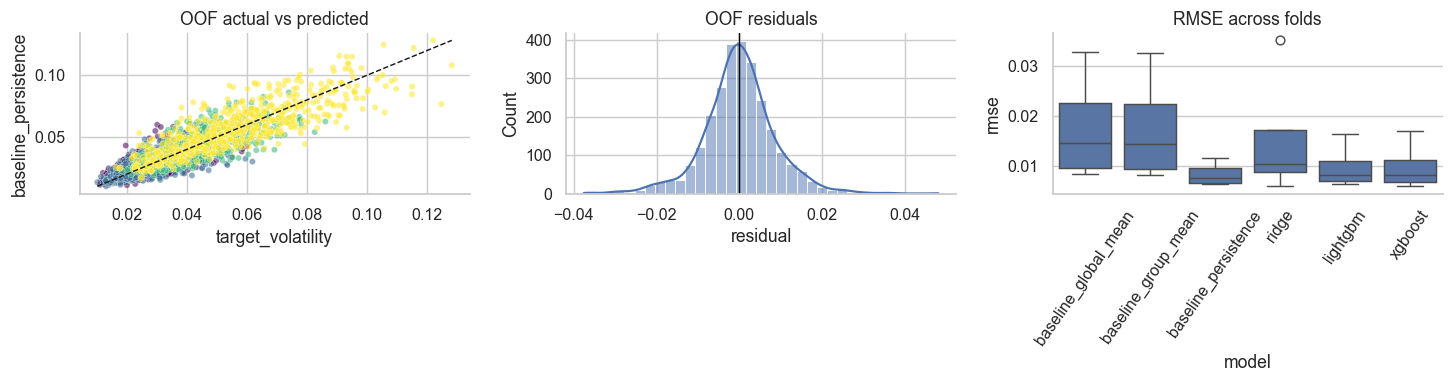

In [16]:
score_table = pd.DataFrame([metric_row(oof, name) for name in model_columns]).sort_values("rmse").reset_index(drop=True)
baseline_scores = score_table.loc[score_table["model"].isin(BASELINE_NAMES)].sort_values("rmse")
best_baseline_model, best_baseline_rmse = str(baseline_scores.iloc[0]["model"]), baseline_scores.iloc[0]["rmse"]
score_table["skill_vs_best_baseline"] = 1 - score_table["rmse"] / best_baseline_rmse
selected_model = str(score_table.iloc[0]["model"])
fold_scores = pd.DataFrame([{"fold": fold, **metric_row(group, name)}
    for fold, group in oof.groupby("fold") for name in model_columns])
selection_record = {"selected_model": selected_model, "selection_metric": "pooled_oof_rmse",
                    "locked_baseline": best_baseline_model, "oof_rows": len(oof),
                    "baseline_retained": selected_model in BASELINE_NAMES, "learned_oof_is_nested": True}
chosen = oof[[ROW_ID_COL, TIME_COL, ENTITY_COL, GROUP_COL, TARGET_COL, "macro_vol_index", "fold", selected_model]].copy()
chosen["residual"] = chosen[TARGET_COL] - chosen[selected_model]
chosen["absolute_error"] = chosen["residual"].abs()
display(score_table.round(6)); display(fold_scores.pivot(index="fold", columns="model", values="rmse").round(6)); print(selection_record)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
sns.scatterplot(data=chosen, x=TARGET_COL, y=selected_model, hue="fold", palette="viridis", s=18, alpha=.55, ax=axes[0], legend=False)
low, high = chosen[[TARGET_COL, selected_model]].min().min(), chosen[[TARGET_COL, selected_model]].max().max(); axes[0].plot([low, high], [low, high], "k--", lw=1)
sns.histplot(data=chosen, x="residual", bins=35, kde=True, ax=axes[1]); axes[1].axvline(0, color="black", lw=1)
sns.boxplot(data=fold_scores, x="model", y="rmse", ax=axes[2]); axes[2].tick_params(axis="x", rotation=55)
axes[0].set_title("OOF actual vs predicted"); axes[1].set_title("OOF residuals"); axes[2].set_title("RMSE across folds")
plt.tight_layout(); plt.show()


## R13.11 · Diagnose time and groups, then open the final block once
<a id="r13-11"></a>

**Topic** Model diagnostics

**Use when** the rule is locked and the remaining questions concern stability, final evidence and delivery.

**Inputs** selected rule, OOF ledger, sealed dates, full labeled panel, future panel and output template.

**Needs** R13.10

**Gotchas** the selected rule and the locked best baseline are both scored on identical sealed rows, but the result never triggers a switch. Refit includes all labeled dates only after that report.

**See also** [R13.6](#r13-6) (sealed dates) · [R13.10](#r13-10) (locked rule)


,n,bias,mae
sector,,,
energy,576,0.000055,0.005225
finance,576,0.000066,0.006872
health,576,-0.000009,0.006480
industrial,480,0.000019,0.006352
technology,480,0.000046,0.006389


,n,bias,mae
volatility_regime,,,
low,840,0.000933,0.004715
middle,1008,0.000369,0.005301
high,840,-0.001260,0.008943


,n,tail_rate
sector,,
energy,576,0.0226
finance,576,0.0712
health,576,0.0486
industrial,480,0.0458
technology,480,0.0646


,n,bias,mae
asset_id,,,
A002,96,-0.000066,0.009537
A008,96,-0.000006,0.009469
A004,96,0.000127,0.009159
A016,96,0.000126,0.008935
A009,96,-0.000002,0.008603
A006,96,0.000074,0.007912
A022,96,-0.000024,0.007151
A012,96,0.000034,0.006945


{'worst_date_rmse': np.float64(0.02242602169978906), 'mean_within_fold_entity_residual_lag1': np.float64(-0.3016658701170659), 'p95_absolute_error': np.float64(0.018151492270961522), 'rank_ic_summary': {'valid_dates': 96, 'total_dates': 96, 'mean': np.float64(0.8466178617040686), 'std': np.float64(0.04595275722801743), 'worst': np.float64(0.7471264367816092)}}


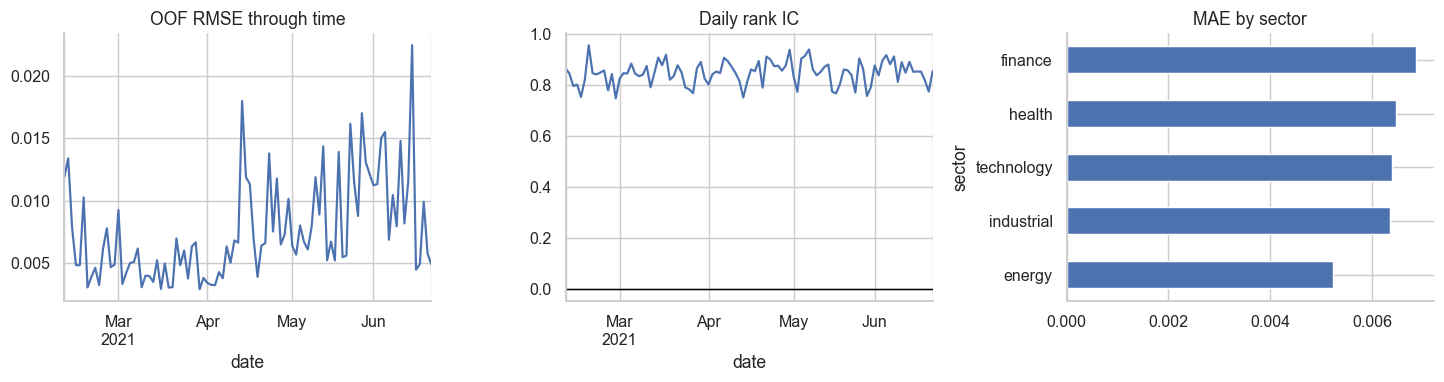

In [17]:
date_diagnostic = chosen.groupby(TIME_COL).agg(n=(TARGET_COL, "size"), bias=("residual", "mean"),
    mae=("absolute_error", "mean"), mse=("residual", lambda values: np.mean(np.square(values))))
date_diagnostic["rmse"] = np.sqrt(date_diagnostic.pop("mse")); date_diagnostic["rank_ic"] = date_rank_ic(chosen, selected_model)
group_diagnostic = chosen.groupby(GROUP_COL, observed=True).agg(n=(TARGET_COL, "size"), bias=("residual", "mean"), mae=("absolute_error", "mean"))
entity_diagnostic = chosen.groupby(ENTITY_COL, observed=True).agg(n=(TARGET_COL, "size"), bias=("residual", "mean"), mae=("absolute_error", "mean")).sort_values("mae", ascending=False)
regime_rank = chosen["macro_vol_index"].rank(pct=True, method="average")
chosen["volatility_regime"] = pd.cut(regime_rank, [0, 1/3, 2/3, 1], labels=["low", "middle", "high"], include_lowest=True)
regime_diagnostic = chosen.groupby("volatility_regime", observed=True).agg(n=(TARGET_COL, "size"), bias=("residual", "mean"), mae=("absolute_error", "mean"))
entity_rho = pd.Series({key: group["residual"].corr(group["residual"].shift(1)) for key, group in
    chosen.sort_values(["fold", ENTITY_COL, TIME_COL]).groupby(["fold", ENTITY_COL], observed=True)})
tail_cutoff = chosen["absolute_error"].quantile(.95); chosen["is_tail"] = chosen["absolute_error"].ge(tail_cutoff)
tail_by_group = chosen.groupby(GROUP_COL, observed=True).agg(n=(TARGET_COL, "size"), tail_rate=("is_tail", "mean"))
valid_ic = date_diagnostic["rank_ic"].dropna(); ic_summary = {"valid_dates": len(valid_ic), "total_dates": len(date_diagnostic),
    "mean": valid_ic.mean(), "std": valid_ic.std(), "worst": valid_ic.min()}
display(group_diagnostic.round(6)); display(regime_diagnostic.round(6)); display(tail_by_group.round(4)); display(entity_diagnostic.head(8).round(6))
print({"worst_date_rmse": date_diagnostic["rmse"].max(), "mean_within_fold_entity_residual_lag1": entity_rho.mean(),
       "p95_absolute_error": tail_cutoff, "rank_ic_summary": ic_summary})
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
date_diagnostic[["rmse"]].plot(ax=axes[0], legend=False); axes[0].set_title("OOF RMSE through time")
date_diagnostic[["rank_ic"]].plot(ax=axes[1], legend=False); axes[1].axhline(0, color="black", lw=1); axes[1].set_title("Daily rank IC")
group_diagnostic.sort_values("mae")["mae"].plot.barh(ax=axes[2]); axes[2].set_title("MAE by sector")
plt.tight_layout(); plt.show()


The OOF diagnostics above remain the main debugging surface. Only now is the sealed block scored, followed by a final fit on every labeled date and an ID-aligned future output.


In [18]:
def fit_and_predict(name, fit_frame, score_frame):
    if name in searches:
        fitted = clone(searches[name].best_estimator_).fit(fit_frame[feature_columns], fit_frame[TARGET_COL])
        return fitted, fitted.predict(score_frame[feature_columns])
    return None, baseline_predict(name, fit_frame, score_frame)
sealed_rules = list(dict.fromkeys([selected_model, best_baseline_model])); sealed_predictions = {}
for name in sealed_rules: _, sealed_predictions[name] = fit_and_predict(name, development, sealed_final)
sealed_report = pd.DataFrame([{"rule": name, "role": "selection_and_baseline" if selected_model == best_baseline_model else
    ("locked_selection" if name == selected_model else "locked_baseline"), "rows": len(sealed_final),
    "rmse": rmse(sealed_final[TARGET_COL], prediction), "mae": mean_absolute_error(sealed_final[TARGET_COL], prediction)}
    for name, prediction in sealed_predictions.items()])
baseline_rmse = sealed_report.loc[sealed_report["rule"].eq(best_baseline_model), "rmse"].iloc[0]
sealed_report["skill_vs_locked_baseline"] = 1 - sealed_report["rmse"] / baseline_rmse
full_labeled = train_panel.sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
final_model, future_prediction = fit_and_predict(selected_model, full_labeled, future_panel)
prediction_frame = future_panel[[ROW_ID_COL]].assign(**{PREDICTION_COL: future_prediction})
submission = sample_output[[ROW_ID_COL]].merge(prediction_frame, on=ROW_ID_COL, how="left", validate="one_to_one", sort=False)
assert np.array_equal(submission[ROW_ID_COL].to_numpy(), sample_output[ROW_ID_COL].to_numpy())
assert len(submission) == len(sample_output) and submission[ROW_ID_COL].is_unique
assert list(submission.columns) == [ROW_ID_COL, PREDICTION_COL] and np.isfinite(submission[PREDICTION_COL]).all()
assert submission[PREDICTION_COL].gt(0).all()
display(sealed_report); print({"final_fit_rows": len(full_labeled), "future_rows": len(submission), "sample_order_preserved": True})
submission.head()


,rule,role,rows,rmse,mae,skill_vs_locked_baseline
0,baseline_persistence,selection_and_baseline,756,0.011149,0.008025,0.0


{'final_fit_rows': 4200, 'future_rows': 720, 'sample_order_preserved': True}


,row_id,prediction
0,te_000517,0.043378
1,te_000705,0.040968
2,te_000452,0.057552
3,te_000331,0.035014
4,te_000442,0.052834


## Verdict & what carries forward

The notebook leaves a reproducible evidence chain:

raw inventory → deterministic cleaning → validated multi-table joins → causal panel features → role and drift audit → purged date folds mapped to rows → fold-fitted pipelines → nested compact tuning → one honest OOF ledger → pooled selection → time, regime, sector and entity diagnostics → selected-versus-baseline sealed evidence → all-history refit → ID-aligned predictions.

For a new dataset, finish by writing down three facts beside the final tables: the chosen rule and its improvement over the strongest valid baseline; the worst instability visible across dates or groups; and the single data or modeling change most likely to resolve that failure. Save `submission` only after its schema, row order and finite-value assertions pass.
